# **Graphics Results Producing Notebook**
This notebook enables creating graphic Illustrations for experiments results.
Full guidlines list can be found in the READ-ME.

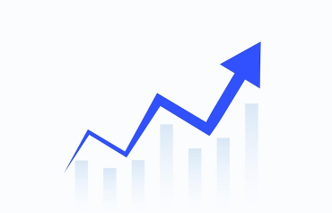

#### **Preparing**: libraries importing, folders creating
import all relevant libs. Also, create directories that may hold the training data for all examined models - and a "save" folder that may hold the graphic results images.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

!pip install torchview graphviz
from torchview import draw_graph
import torchvision.models as models
import torch.nn.functional as F

# Create directories for saving models and figures if they don't exist
save_path = '/content/save'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print('Create path : {}'.format(save_path))
save_path = '/content/M1'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print('Create path : {}'.format(save_path))
save_path = '/content/M2'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print('Create path : {}'.format(save_path))
save_path = '/content/M3'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print('Create path : {}'.format(save_path))

Create path : /content/save
Create path : /content/M1
Create path : /content/M2
Create path : /content/M3


### **PART A:** Training metrics graphs

#### **Function 1:** Plot graphs of a single model training metrics (if they all exist)

In [ ]:
def plot_validation_metrics(save_path, model_name='RED-CNN', output_dir='.'):
    """
    Loads saved validation metrics and plots them.
    save_path: The directory where the .npy files were saved (e.g., '/content/save/')
    model_name: The name of the model to display in the plot title.
    """
    # Load the arrays
    try:
        val_losses = np.load(os.path.join(save_path, 'valid_loss.npy'))
        psnr_deltas = np.load(os.path.join(save_path, 'valid_psnr_delta.npy'))
        ssim_deltas = np.load(os.path.join(save_path, 'valid_ssim_delta.npy'))
        rmse_deltas = np.load(os.path.join(save_path, 'valid_rmse_delta.npy'))

        train_losses = np.load(os.path.join(save_path, 'epoch_train_loss.npy'))
        lrs = np.load(os.path.join(save_path, 'epoch_lrs.npy'))

    except FileNotFoundError as e:
        print(f"Error loading files: {e}")
        return

    epochs = range(1, len(val_losses) + 1)

    # Set up a 2x3 grid for plotting
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{model_name} - Metrics Over Epochs', fontsize=16)

    # Plot 1: Train & Validation Loss (Combined)
    axs[0, 0].plot(epochs, train_losses, label='Train Loss', color='tab:orange', linewidth=2)
    axs[0, 0].plot(epochs, val_losses, label='Validation Loss', color='tab:red', linewidth=2)
    axs[0, 0].set_title('Training vs Validation Loss')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('MSE Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Learning Rate
    axs[0, 1].plot(epochs, lrs, color='tab:cyan', linewidth=2)
    axs[0, 1].set_title('Learning Rate Schedule')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Learning Rate')
    axs[0, 1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Plot 3: PSNR Delta
    axs[0, 2].plot(epochs, psnr_deltas, color='tab:blue', linewidth=2)
    axs[0, 2].set_title('PSNR Improvement (Delta)')
    axs[0, 2].set_xlabel('Epochs')
    axs[0, 2].set_ylabel('Δ PSNR (dB)')
    axs[0, 2].grid(True, linestyle='--', alpha=0.7)

    # Plot 4: SSIM Delta
    axs[1, 0].plot(epochs, ssim_deltas, color='tab:green', linewidth=2)
    axs[1, 0].set_title('SSIM Improvement (Delta)')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Δ SSIM')
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Plot 5: RMSE Delta
    axs[1, 1].plot(epochs, rmse_deltas, color='tab:purple', linewidth=2)
    axs[1, 1].set_title('RMSE Reduction (Delta)')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Δ RMSE')
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)

    # Hide the 6th empty subplot (bottom right)
    fig.delaxes(axs[1, 2])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout so title doesn't overlap

    # Save to disk and display in the notebook output:
    save_file = os.path.join(output_dir, f'{model_name} - Metrics Over Epochs.png')
    fig.savefig(save_file)
    plt.show()
    plt.close()

#### **Function 2:** Plot graphs of 2 models training metrics (skipping non exist metrics)

In [ ]:
def plot_validation_metrics_comparison(save_path_1, save_path_2, model_name_1='Model 1', model_name_2='Model 2', output_dir='.'):
    """
    Loads saved validation metrics from two different directories and plots them side-by-side.
    Handles missing files.
    """

    # Helper function to load arrays safely without crashing
    def load_metrics(path):
        def safe_load(filename):
            full_path = os.path.join(path, filename)
            if os.path.exists(full_path):
                return np.load(full_path)
            else:
                print(f"Warning: {filename} not found in {path}. Skipping this metric.")
                return None

        # Check for both lr name variations just in case
        lr_data = safe_load('epoch_lrs.npy')
        if lr_data is None:
            lr_data = safe_load('epoch_lrs.npy')

        metrics = {
            'val_losses': safe_load('valid_loss.npy'),
            'psnr_deltas': safe_load('valid_psnr_delta.npy'),
            'ssim_deltas': safe_load('valid_ssim_delta.npy'),
            'rmse_deltas': safe_load('valid_rmse_delta.npy'),
            'lrs': lr_data
        }
        return metrics

    # Load metrics for both models
    print(f"Loading data for {model_name_1}...")
    m1 = load_metrics(save_path_1)

    print(f"\nLoading data for {model_name_2}...")
    m2 = load_metrics(save_path_2)

    # must have at least val_losses to establish the timeline
    if m1['val_losses'] is None or m2['val_losses'] is None:
        print("\nAborting plot: Missing critical 'valid_loss.npy' in one or both directories.")
        return

    epochs1 = range(1, len(m1['val_losses']) + 1)
    epochs2 = range(1, len(m2['val_losses']) + 1)

    # Set up a 2x3 grid for plotting
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Comparison: {model_name_1} vs {model_name_2}', fontsize=18, fontweight='bold')

    # Plot 1: Validation Losses
    axs[0, 0].plot(epochs1, m1['val_losses'], label=f'{model_name_1} Val', color='tab:red', linewidth=2)
    axs[0, 0].plot(epochs2, m2['val_losses'], label=f'{model_name_2} Val', color='tab:blue', linewidth=2)
    axs[0, 0].set_title('Validation Loss')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('MSE Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Learning Rate
    if m1['lrs'] is not None:
        axs[0, 1].plot(epochs1, m1['lrs'], label=model_name_1, color='tab:red', linewidth=2)
    if m2['lrs'] is not None:
        axs[0, 1].plot(epochs2, m2['lrs'], label=model_name_2, color='tab:blue', linewidth=2)

    axs[0, 1].set_title('Learning Rate Schedule')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Learning Rate')
    axs[0, 1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    if m1['lrs'] is not None or m2['lrs'] is not None:
        axs[0, 1].legend()
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Plot 3: PSNR Delta
    if m1['psnr_deltas'] is not None:
        axs[0, 2].plot(epochs1, m1['psnr_deltas'], label=model_name_1, color='tab:red', linewidth=2)
    if m2['psnr_deltas'] is not None:
        axs[0, 2].plot(epochs2, m2['psnr_deltas'], label=model_name_2, color='tab:blue', linewidth=2)
    axs[0, 2].set_title('PSNR Improvement (Delta)')
    axs[0, 2].set_xlabel('Epochs')
    axs[0, 2].set_ylabel('Δ PSNR (dB)')
    axs[0, 2].legend()
    axs[0, 2].grid(True, linestyle='--', alpha=0.7)

    # Plot 4: SSIM Delta
    if m1['ssim_deltas'] is not None:
        axs[1, 0].plot(epochs1, m1['ssim_deltas'], label=model_name_1, color='tab:red', linewidth=2)
    if m2['ssim_deltas'] is not None:
        axs[1, 0].plot(epochs2, m2['ssim_deltas'], label=model_name_2, color='tab:blue', linewidth=2)
    axs[1, 0].set_title('SSIM Improvement (Delta)')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Δ SSIM')
    axs[1, 0].legend()
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Plot 5: RMSE Delta
    if m1['rmse_deltas'] is not None:
        axs[1, 1].plot(epochs1, m1['rmse_deltas'], label=model_name_1, color='tab:red', linewidth=2)
    if m2['rmse_deltas'] is not None:
        axs[1, 1].plot(epochs2, m2['rmse_deltas'], label=model_name_2, color='tab:blue', linewidth=2)
    axs[1, 1].set_title('RMSE Reduction (Delta)')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Δ RMSE')
    axs[1, 1].legend()
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)

    # Hide the 6th empty subplot (bottom right)
    fig.delaxes(axs[1, 2])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save and display
    save_file = os.path.join(output_dir, f'Comparison_{model_name_1}_vs_{model_name_2}.png')
    fig.savefig(save_file)
    print(f"\nPlot saved successfully to: {save_file}")

    plt.show()
    plt.close()

#### **Function 3:** Plot graphs of 3 models training metrics (skipping non exist metrics)

In [ ]:
def plot_3_models_comparison(save_path_1, save_path_2, save_path_3,
                             model_name_1='Model 1', model_name_2='Model 2', model_name_3='Model 3',
                             output_dir='.', show_lr=False):
    """
    Loads saved validation metrics from 3 different directories and plots them side-by-side.
    Handles missing files.
    If show_lr is False, the Learning Rate plot is omitted and a 2x2 grid is used.
    """

    # Helper function to load arrays safely
    def load_metrics(path):
        def safe_load(filename):
            full_path = os.path.join(path, filename)
            if os.path.exists(full_path):
                return np.load(full_path)
            else:
                print(f"Warning: {filename} not found in {path}. Skipping this metric.")
                return None

        # Check for both lr name variations just in case
        lr_data = safe_load('epoch_lrs.npy')
        if lr_data is None:
            lr_data = safe_load('epoch_lrs.npy')

        metrics = {
            'val_losses': safe_load('valid_loss.npy'),
            'psnr_deltas': safe_load('valid_psnr_delta.npy'),
            'ssim_deltas': safe_load('valid_ssim_delta.npy'),
            'rmse_deltas': safe_load('valid_rmse_delta.npy'),
            'train_losses': safe_load('epoch_train_loss.npy'),
            'lrs': lr_data
        }
        return metrics

    # Load metrics for all three models
    print(f"Loading data for {model_name_1}...")
    m1 = load_metrics(save_path_1)
    print(f"Loading data for {model_name_2}...")
    m2 = load_metrics(save_path_2)
    print(f"Loading data for {model_name_3}...")
    m3 = load_metrics(save_path_3)

    if m1['val_losses'] is None or m2['val_losses'] is None or m3['val_losses'] is None:
        print("\nAborting plot: Missing critical 'valid_loss.npy' in one or more directories.")
        return

    epochs1 = range(1, len(m1['val_losses']) + 1)
    epochs2 = range(1, len(m2['val_losses']) + 1)
    epochs3 = range(1, len(m3['val_losses']) + 1)

    # Dynamic Grid Setup
    if show_lr:
        fig, axs = plt.subplots(2, 3, figsize=(18, 10))
        ax_loss = axs[0, 0]
        ax_lr   = axs[0, 1]
        ax_psnr = axs[0, 2]
        ax_ssim = axs[1, 0]
        ax_rmse = axs[1, 1]
        fig.delaxes(axs[1, 2]) # Remove empty bottom-right subplot
    else:
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        ax_loss = axs[0, 0]
        ax_psnr = axs[0, 1]
        ax_ssim = axs[1, 0]
        ax_rmse = axs[1, 1]

    fig.suptitle(f'{model_name_1} | {model_name_2} | {model_name_3}', fontsize=18, fontweight='bold')

    # Plot 1: Train & Validation Loss
    if m1['train_losses'] is not None:
        ax_loss.plot(epochs1, m1['train_losses'], label=f'{model_name_1} Train', color='tab:orange', linestyle='--', linewidth=2)
    ax_loss.plot(epochs1, m1['val_losses'], label=f'{model_name_1} Val', color='tab:red', linewidth=2)
    if m2['train_losses'] is not None:
        ax_loss.plot(epochs2, m2['train_losses'], label=f'{model_name_2} Train', color='tab:cyan', linestyle='--', linewidth=2)
    ax_loss.plot(epochs2, m2['val_losses'], label=f'{model_name_2} Val', color='tab:blue', linewidth=2)
    if m3['train_losses'] is not None:
        ax_loss.plot(epochs3, m3['train_losses'], label=f'{model_name_3} Train', color='tab:olive', linestyle='--', linewidth=2)
    ax_loss.plot(epochs3, m3['val_losses'], label=f'{model_name_3} Val', color='tab:green', linewidth=2)

    ax_loss.set_title('Training vs Validation Loss', fontsize=12)
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('MSE Loss')
    ax_loss.legend(fontsize=12)
    ax_loss.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Learning Rate (Conditional)
    if show_lr:
        if m1['lrs'] is not None:
            ax_lr.plot(epochs1, m1['lrs'], label=model_name_1, color='tab:red', linewidth=2)
        if m2['lrs'] is not None:
            ax_lr.plot(epochs2, m2['lrs'], label=model_name_2, color='tab:blue', linewidth=2)
        if m3['lrs'] is not None:
            ax_lr.plot(epochs3, m3['lrs'], label=model_name_3, color='tab:green', linewidth=2)

        ax_lr.set_title('Learning Rate Schedule', fontsize=12)
        ax_lr.set_xlabel('Epochs')
        ax_lr.set_ylabel('Learning Rate')
        ax_lr.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        if m1['lrs'] is not None or m2['lrs'] is not None or m3['lrs'] is not None:
            ax_lr.legend(fontsize=12)
        ax_lr.grid(True, linestyle='--', alpha=0.7)

    # Plot 3: PSNR Delta
    if m1['psnr_deltas'] is not None:
        ax_psnr.plot(epochs1, m1['psnr_deltas'], label=model_name_1, color='tab:red', linewidth=2)
    if m2['psnr_deltas'] is not None:
        ax_psnr.plot(epochs2, m2['psnr_deltas'], label=model_name_2, color='tab:blue', linewidth=2)
    if m3['psnr_deltas'] is not None:
        ax_psnr.plot(epochs3, m3['psnr_deltas'], label=model_name_3, color='tab:green', linewidth=2)

    ax_psnr.set_title('PSNR Improvement (Delta)', fontsize=12)
    ax_psnr.set_xlabel('Epochs')
    ax_psnr.set_ylabel('Δ PSNR (dB)')
    ax_psnr.legend(fontsize=12)
    ax_psnr.grid(True, linestyle='--', alpha=0.7)

    # Plot 4: SSIM Delta
    if m1['ssim_deltas'] is not None:
        ax_ssim.plot(epochs1, m1['ssim_deltas'], label=model_name_1, color='tab:red', linewidth=2)
    if m2['ssim_deltas'] is not None:
        ax_ssim.plot(epochs2, m2['ssim_deltas'], label=model_name_2, color='tab:blue', linewidth=2)
    if m3['ssim_deltas'] is not None:
        ax_ssim.plot(epochs3, m3['ssim_deltas'], label=model_name_3, color='tab:green', linewidth=2)

    ax_ssim.set_title('SSIM Improvement (Delta)', fontsize=12)
    ax_ssim.set_xlabel('Epochs')
    ax_ssim.set_ylabel('Δ SSIM')
    ax_ssim.legend(fontsize=12)
    ax_ssim.grid(True, linestyle='--', alpha=0.7)

    # Plot 5: RMSE Delta
    if m1['rmse_deltas'] is not None:
        ax_rmse.plot(epochs1, m1['rmse_deltas'], label=model_name_1, color='tab:red', linewidth=2)
    if m2['rmse_deltas'] is not None:
        ax_rmse.plot(epochs2, m2['rmse_deltas'], label=model_name_2, color='tab:blue', linewidth=2)
    if m3['rmse_deltas'] is not None:
        ax_rmse.plot(epochs3, m3['rmse_deltas'], label=model_name_3, color='tab:green', linewidth=2)

    ax_rmse.set_title('RMSE Reduction (Delta)', fontsize=12)
    ax_rmse.set_xlabel('Epochs')
    ax_rmse.set_ylabel('Δ RMSE')
    ax_rmse.legend(fontsize=12)
    ax_rmse.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save and display
    save_file = os.path.join(output_dir, f'Comparison_{model_name_1}_vs_{model_name_2}_vs_{model_name_3}.png')
    fig.savefig(save_file)
    print(f"\nPlot saved successfully to: {save_file}")

    plt.show()
    plt.close()

#### **Optional**: Models naming and running exemples
Naming models according to their names in the report. Also, one can see exmaples for running the plotting functions.

`User Note:` the metrics files of each model should be **uploaded manualy** by the user for the corresponding folders, **before** running the functions.

In [ ]:
# Naming Models:
# RED CNN
m1 = 'Mayo RED-CNN'
m2 = 'MAR RED-CNN'
m3 = 'M1 Fine-tuned RED-CNN on MAR'
m4 = 'M1 Fine-tuned decoder RED-CNN on MAR'

# UNet18
m5 = 'Mayo UNet18'
m6 = 'Mayo Tailored UNet18'
m7 = 'ImageNet Fine-tuned UNet18 on MAR'
m8 = 'M6 Fine-tuned Unet18 on MAR'
m9 = 'M6 Fine-tuned Unet18 on MAR with Optuna'
m10 = 'M6 Fine-tuned Unet18 on MAR with Optuna and Cosine sched.'
m11 = 'M6 Fine-tuned Unet18 on MAR with Optuna and Augment.'

In [ ]:
plot_validation_metrics('./M1/', model_name=m11, output_dir='/content/save/')

In [ ]:
plot_validation_metrics_comparison(
    save_path_1='./M1/',
    save_path_2='./M2/',
    model_name_1='ImageNet Fine-tuned UNet18 on MAR',
    model_name_2='M6 Fine-tuned Unet18 on MAR',
    output_dir='/content/save/'
)

In [ ]:
plot_3_models_comparison_no_loss(
    save_path_1='./M1/',
    save_path_2='./M2/',
    save_path_3='./M3/',
    model_name_1=m9,
    model_name_2=m10,
    model_name_3=m11,
    output_dir='/content/save/'
)

### **PART B:** Implementation Visualization

One can copy its model architecture class and see a visual graph of the model. An example for Unet18 can be observed

In [ ]:
class ResNet18EncoderDecoder(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(ResNet18EncoderDecoder, self).__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # -- ENCODER INIT --
        # Getting the original pre-trained 3-channel conv1
        original_conv1 = resnet.conv1

        # B is batch size
        # Input size: [B, 1, 256, 256]
        self.first_conv = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False) # Out: [B, 64, 128, 128]

        # Using Transfer Learning: Summing the pre-trained weights across the RGB channels - to get 1 channel, the grayscale
        with torch.no_grad():
            self.first_conv.weight.copy_(original_conv1.weight.sum(dim=1, keepdim=True))

        # Carry over the rest of the pre-trained layers
        self.first_bn = resnet.bn1 #  Batch Normalization
        self.first_relu = resnet.relu
        self.first_pool = resnet.maxpool # Out: [B, 64, 64, 64]

        self.encoder1 = resnet.layer1 # Out: [B, 64, 64, 64]
        self.encoder2 = resnet.layer2 # Out: [B, 128, 32, 32]
        self.encoder3 = resnet.layer3 # Out: [B, 256, 16, 16]
        self.encoder4 = resnet.layer4 # Out: [B, 512, 8, 8]

        # -- DECODER INIT --
        # 1st upsample: 8x8 -> 16x16
        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) # Out: [B, 256, 16, 16]
        self.decoder4 = self._decoder_block(512, 256) # In: 256 (up) + 256 (skip) = 512. Out: [B, 256, 16, 16]

        # 2nd upsample: 16x16 -> 32x32
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # Out: [B, 128, 32, 32]
        self.decoder3 = self._decoder_block(256, 128) # In: 128 (up) + 128 (skip) = 256. Out: [B, 128, 32, 32]

        # 3rd upsample: 32x32 -> 64x64
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)  # Out: [B, 64, 64, 64]
        self.decoder2 = self._decoder_block(128, 64)  # In: 64 (up) + 64 (skip) = 128. Out: [B, 64, 64, 64]

        # 4th upsample: 64x64 -> 128x128
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)   # Out: [B, 64, 128, 128]
        self.decoder1 = self._decoder_block(128, 64)  # In: 64 (up) + 64 (skip from e0) = 128. Out: [B, 64, 128, 128]

        # 5th upsample: 128x128 -> 256x256 (Original Size)
        self.upconv0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)   # Out: [B, 32, 256, 256]
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=3, padding=1) # Out: [B, 1, 256, 256]

    def _decoder_block(self, in_channels, out_channels):
        # write as a block of code instead of writing 5 times
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # -- ENCODER FLOW --
        # Input 'x' shape: [B, 1, 256, 256]

        e0 = self.first_relu(self.first_bn(self.first_conv(x))) # Shape: [B, 64, 128, 128]
        e0_pool = self.first_pool(e0)                           # Shape: [B, 64, 64, 64]

        e1 = self.encoder1(e0_pool)                             # Shape: [B, 64, 64, 64]
        e2 = self.encoder2(e1)                                  # Shape: [B, 128, 32, 32]
        e3 = self.encoder3(e2)                                  # Shape: [B, 256, 16, 16]
        e4 = self.encoder4(e3)                                  # Shape: [B, 512, 8, 8]

        # -- DECODER FLOW --
        d4 = self.upconv4(e4)                                   # Shape: [B, 256, 16, 16]
        # safety check before skip connection that the layes have the same channel number
        if d4.size() != e3.size():
            d4 = F.interpolate(d4, size=(e3.size(2), e3.size(3)), mode='bilinear', align_corners=False)
        d4 = torch.cat((d4, e3), dim=1)                         # Concat channels: 256 + 256. Shape: [B, 512, 16, 16]
        d4 = self.decoder4(d4)                                  # Process block. Shape: [B, 256, 16, 16]

        d3 = self.upconv3(d4)                                   # Shape: [B, 128, 32, 32]
        if d3.size() != e2.size():
            d3 = F.interpolate(d3, size=(e2.size(2), e2.size(3)), mode='bilinear', align_corners=False)
        d3 = torch.cat((d3, e2), dim=1)                         # Concat channels: 128 + 128. Shape: [B, 256, 32, 32]
        d3 = self.decoder3(d3)                                  # Process block. Shape: [B, 128, 32, 32]

        d2 = self.upconv2(d3)                                   # Shape: [B, 64, 64, 64]
        if d2.size() != e1.size():
            d2 = F.interpolate(d2, size=(e1.size(2), e1.size(3)), mode='bilinear', align_corners=False)
        d2 = torch.cat((d2, e1), dim=1)                         # Concat channels: 64 + 64. Shape: [B, 128, 64, 64]
        d2 = self.decoder2(d2)                                  # Process block. Shape: [B, 64, 64, 64]

        d1 = self.upconv1(d2)                                   # Shape: [B, 64, 128, 128]
        if d1.size() != e0.size():
            d1 = F.interpolate(d1, size=(e0.size(2), e0.size(3)), mode='bilinear', align_corners=False)
        d1 = torch.cat((d1, e0), dim=1)                         # Concat channels: 64 + 64 (from e0 before pool). Shape: [B, 128, 128, 128]
        d1 = self.decoder1(d1)                                  # Process block. Shape: [B, 64, 128, 128]

        d0 = self.upconv0(d1)                                   # Shape: [B, 32, 256, 256]
        if d0.size() != x.size():
            d0 = F.interpolate(d0, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)

        out = self.final_conv(d0)                               # Shape: [B, 1, 256, 256]

        # Residual connection
        # Both x and out are [B, 1, 256, 256]
        return x + out

In [ ]:
model = ResNet18EncoderDecoder()

graph = draw_graph(
    model,
    input_size=(1, 1, 256, 256),   # Batch=1
    expand_nested=True,
    graph_name="ResNet18EncoderDecoder",
    save_graph=True,
    filename="network"
)

graph.visual_graph